# Parker (1988) — Nanoflares and the Solar X-Ray Corona / 나노플레어 구현

**Paper**: Parker, E. N., *Nanoflares and the Solar X-Ray Corona*, ApJ **330**, 474–479, 1988.

This notebook reproduces Parker's quantitative arguments for the nanoflare hypothesis: the Poynting-flux buildup, the saturation of $W(t) = (B^2/4\pi) v^2 t / L$ at the coronal heating requirement, scale-invariance of the per-discontinuity nanoflare energy, a footpoint random-walk simulation, and a power-law statistical test for nanoflare-dominated heating.

이 노트북은 Parker의 나노플레어 가설을 정량적으로 재현합니다: Poynting flux 축적, $W(t) = (B^2/4\pi) v^2 t / L$이 코로나 가열 요구량에서 포화, 단일 불연속면 나노플레어 에너지의 척도 불변성, 발점 무작위 보행 시뮬레이션, 나노플레어 지배 가열에 대한 거듭제곱 통계 시험.

**Contents / 목차**
1. Linear buildup $W(t)$ until reconnection saturates / 재결합 포화까지 $W(t)$ 선형 축적
2. Scale-invariance: active region vs. X-ray bright point / 척도 불변성
3. Photospheric footpoint random-walk simulation / 광구 발점 무작위 보행
4. Power-law nanoflare distribution: when does $\alpha > 2$ dominate? / 거듭제곱 분포
5. Visualization of magnetic-loop tilting and reconnection threshold / 자기 루프 기울기와 재결합 임계 시각화

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'
rng = np.random.default_rng(42)

## 1. Linear buildup of magnetic free energy / 자유 자기 에너지의 선형 축적

Parker's Eq. 3 says the rate at which photospheric motion does work on the coronal magnetic field is
$$W(t) = \frac{B^2}{4\pi}\,\frac{v^2 t}{L}$$

valid until reconnection saturates the buildup at $W = W_\text{required} \sim 10^7$ erg cm⁻² s⁻¹.

Parker Eq. 3은 광구 운동이 코로나 자기장에 일하는 비율: $W(t) = (B^2/4\pi)(v^2 t/L)$. 재결합이 $W = W_\text{required} \sim 10^7$ erg cm⁻² s⁻¹에서 축적을 포화시킬 때까지 유효.

In [2]:
def parker_W(t, B, v, L):
    """Parker's Eq. 3: heating power per unit area.

    Args:
        t: Time in seconds (array-like).
        B: Vertical field strength in Gauss (CGS).
        v: Photospheric footpoint speed in cm/s.
        L: Loop length in cm.

    Returns:
        Heating power in erg cm^-2 s^-1.
    """
    return (B**2 / (4 * np.pi)) * v**2 * t / L


def saturation_time(B, v, L, W_req=1e7):
    """Time at which W(t) reaches the heating requirement.

    Args:
        B, v, L: As in parker_W.
        W_req: Required heating flux in erg cm^-2 s^-1.

    Returns:
        Saturation time in seconds.
    """
    return 4 * np.pi * W_req * L / (B**2 * v**2)


# Active-region loop parameters (Parker, p. 477)
B_AR = 100.0          # Gauss
v_AR = 0.5e5          # 0.5 km/s in cm/s
L_AR = 1e10           # cm
W_req = 1e7           # erg/cm^2/s

t_sat = saturation_time(B_AR, v_AR, L_AR, W_req)
print(f"Active-region loop / 활동 영역 루프:")
print(f"  B = {B_AR} G,  v = {v_AR/1e5} km/s,  L = {L_AR/1e5:.0e} km")
print(f"  Saturation time t_sat = {t_sat:.2e} s = {t_sat/3600:.2f} hr")
print(f"  Tilt angle θ at saturation = {np.degrees(np.arctan(v_AR * t_sat / L_AR)):.1f}°")
print(f"  Horizontal field B_⊥ at saturation = {B_AR * v_AR * t_sat / L_AR:.1f} G")

Active-region loop / 활동 영역 루프:
  B = 100.0 G,  v = 0.5 km/s,  L = 1e+05 km
  Saturation time t_sat = 5.03e+04 s = 13.96 hr
  Tilt angle θ at saturation = 14.1°
  Horizontal field B_⊥ at saturation = 25.1 G


/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33742/2910207269.py:19: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33742/2910207269.py:19: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33742/2910207269.py:20: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.savefig('fig1_W_buildup.png', dpi=120)
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33742/2910207269.py:20: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.savefig('fig1_W_buildup.png', dpi=120)
/Users/eunsupark/Softwares/miniconda3/envs/study-with-ai/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sa

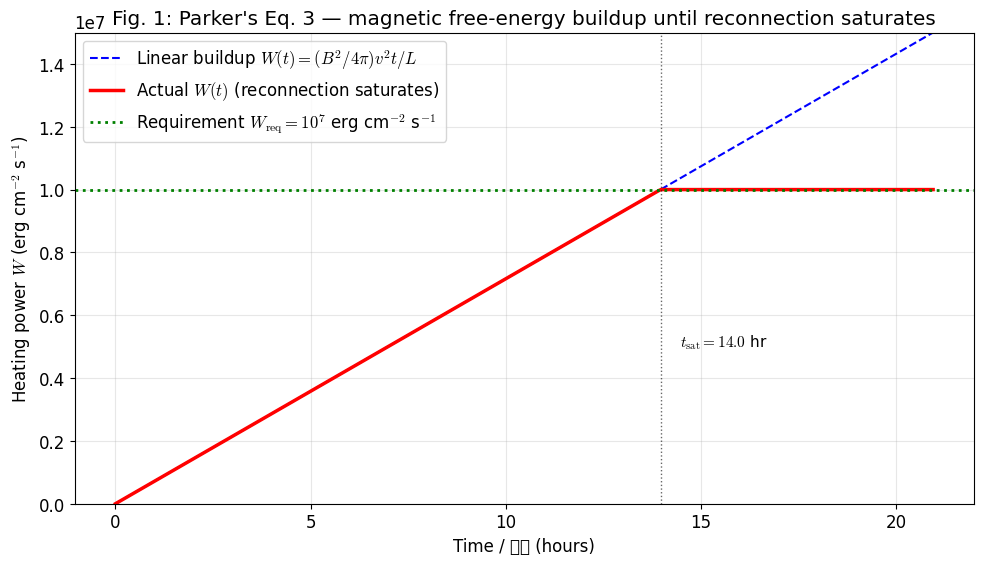

In [3]:
# Plot the buildup
t = np.linspace(0, 1.5 * t_sat, 500)
W = parker_W(t, B_AR, v_AR, L_AR)
W_actual = np.minimum(W, W_req)  # saturate at requirement

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t/3600, W, 'b--', lw=1.5, label=r'Linear buildup $W(t) = (B^2/4\pi) v^2 t/L$')
ax.plot(t/3600, W_actual, 'r-', lw=2.5, label='Actual $W(t)$ (reconnection saturates)')
ax.axhline(W_req, color='green', ls=':', lw=2, label=fr'Requirement $W_\mathrm{{req}} = 10^7$ erg cm$^{{-2}}$ s$^{{-1}}$')
ax.axvline(t_sat/3600, color='black', ls=':', lw=1, alpha=0.6)
ax.text(t_sat/3600 + 0.5, 5e6, fr'$t_\mathrm{{sat}} = {t_sat/3600:.1f}$ hr', fontsize=11)

ax.set_xlabel('Time / 시간 (hours)')
ax.set_ylabel(r'Heating power $W$ (erg cm$^{-2}$ s$^{-1}$)')
ax.set_title("Fig. 1: Parker's Eq. 3 — magnetic free-energy buildup until reconnection saturates")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.5e7)
plt.tight_layout()
plt.savefig('fig1_W_buildup.png', dpi=120)
plt.show()

## 2. Scale-invariance: active region vs. X-ray bright point / 척도 불변성

Parker's key prediction: while saturation *time* depends on $L$, the per-discontinuity nanoflare energy $\mathcal{E} = l^2 \Delta L B_\perp^2 / 8\pi$ is **independent of $L$**, because $\Delta L = L/n$ and $n$ scales with $L$ in such a way that everything cancels.

Parker의 핵심 예측: 포화 *시간*은 $L$에 의존하지만, 단일 불연속면 나노플레어 에너지 $\mathcal{E} = l^2 \Delta L B_\perp^2 / 8\pi$는 **$L$에 무관**. $\Delta L = L/n$이고 $n$이 $L$과 같이 변해 모든 것이 상쇄되기 때문.

In [4]:
def nanoflare_quantities(B, v, L, tau_granule=500.0, W_req=1e7):
    """Compute Parker's nanoflare characteristic quantities.

    Implements Parker (1988) §V "Inferences". Returns the saturation time,
    horizontal-field amplitude at saturation, number of random walk steps,
    wrap length, step length, and characteristic nanoflare energy.

    Args:
        B: Vertical field in Gauss.
        v: Footpoint speed in cm/s.
        L: Loop length in cm.
        tau_granule: Granule lifetime in seconds (default 500 s).
        W_req: Required heating flux in erg cm^-2 s^-1.

    Returns:
        Dict with keys: t_sat, B_perp, n_steps, l_step, dL, energy.
    """
    t_sat = 4 * np.pi * W_req * L / (B**2 * v**2)
    B_perp = B * v * t_sat / L
    n_steps = t_sat / tau_granule
    l_step = v * tau_granule           # cm
    dL = L / n_steps                    # cm
    volume = l_step**2 * dL             # cm^3
    energy = volume * B_perp**2 / (8 * np.pi)  # erg
    return {
        't_sat': t_sat, 'B_perp': B_perp, 'n_steps': n_steps,
        'l_step': l_step, 'dL': dL, 'energy': energy,
    }


# Active region vs X-ray bright point
AR  = nanoflare_quantities(B=100.0, v=0.5e5, L=1e10)
XBP = nanoflare_quantities(B=100.0, v=0.5e5, L=1e9)

print(f"{'Quantity':<32} {'Active region':>20} {'X-ray bright point':>22}")
print("-" * 76)
print(f"{'L [km]':<32} {1e10/1e5:>20.1e} {1e9/1e5:>22.1e}")
print(f"{'Saturation time t_sat [s]':<32} {AR['t_sat']:>20.2e} {XBP['t_sat']:>22.2e}")
print(f"{'Saturation time t_sat [hr]':<32} {AR['t_sat']/3600:>20.2f} {XBP['t_sat']/3600:>22.2f}")
print(f"{'Number of random steps n':<32} {AR['n_steps']:>20.0f} {XBP['n_steps']:>22.0f}")
print(f"{'Step length l [km]':<32} {AR['l_step']/1e5:>20.0f} {XBP['l_step']/1e5:>22.0f}")
print(f"{'Wrap length ΔL [km]':<32} {AR['dL']/1e5:>20.0f} {XBP['dL']/1e5:>22.0f}")
print(f"{'B_perp at saturation [G]':<32} {AR['B_perp']:>20.1f} {XBP['B_perp']:>22.1f}")
print(f"{'Nanoflare energy E [erg]':<32} {AR['energy']:>20.2e} {XBP['energy']:>22.2e}")
print()
print("Note / 참고: B_perp, ΔL, l, and E are nearly identical despite L differing by 10×.")
print("          → Scale-invariant nanoflares — explains scale-invariant X-ray brightness.")

Quantity                                Active region     X-ray bright point
----------------------------------------------------------------------------
L [km]                                        1.0e+05                1.0e+04
Saturation time t_sat [s]                    5.03e+04               5.03e+03
Saturation time t_sat [hr]                      13.96                   1.40
Number of random steps n                          101                     10
Step length l [km]                                250                    250
Wrap length ΔL [km]                               995                    995
B_perp at saturation [G]                         25.1                   25.1
Nanoflare energy E [erg]                     1.56e+24               1.56e+24

Note / 참고: B_perp, ΔL, l, and E are nearly identical despite L differing by 10×.
          → Scale-invariant nanoflares — explains scale-invariant X-ray brightness.


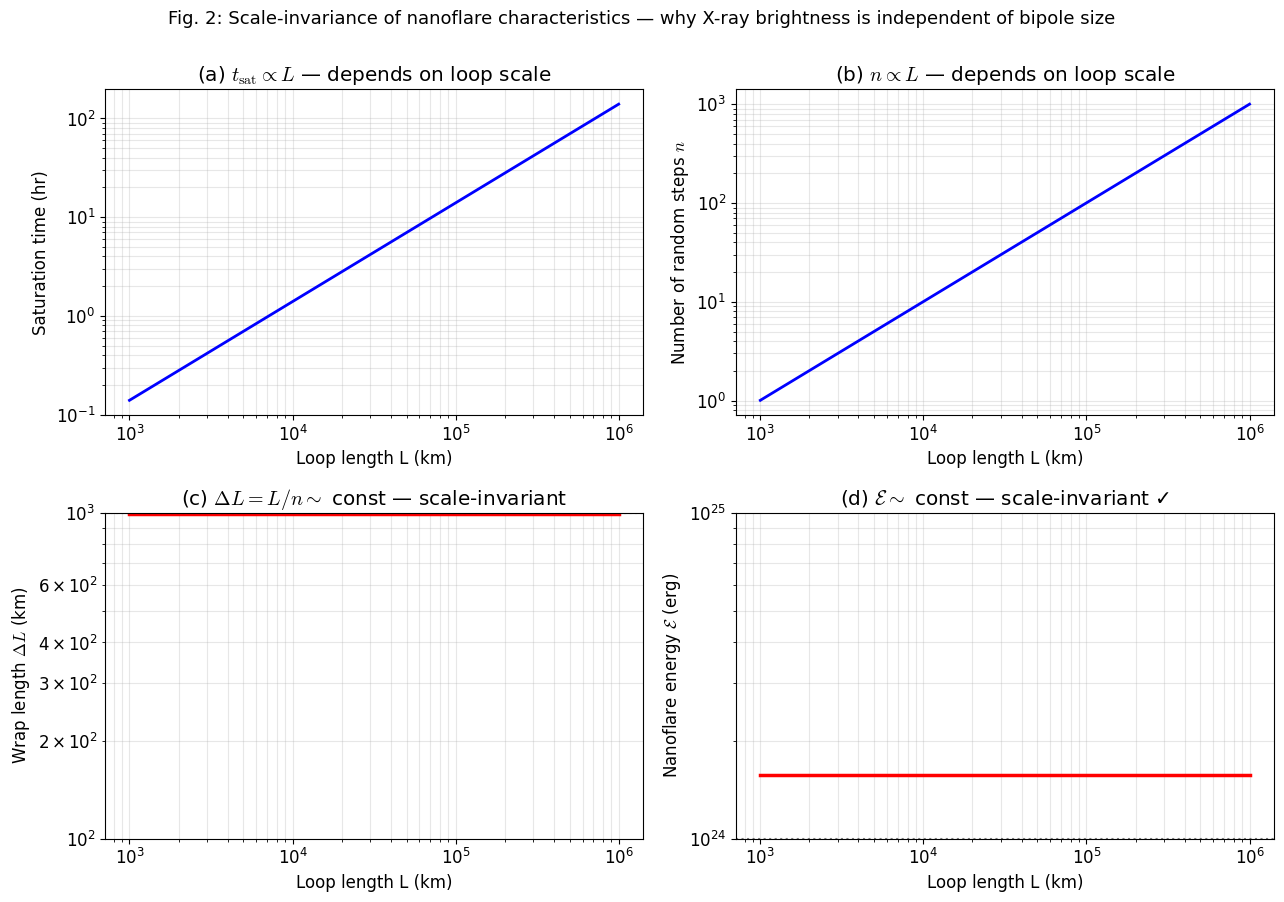

In [5]:
# Visualize how each quantity scales with L
L_grid = np.logspace(8, 11, 50)  # 10^8 to 10^11 cm
results = [nanoflare_quantities(B=100.0, v=0.5e5, L=Li) for Li in L_grid]

t_sat_arr = np.array([r['t_sat'] for r in results])
n_steps_arr = np.array([r['n_steps'] for r in results])
dL_arr = np.array([r['dL'] for r in results])
energy_arr = np.array([r['energy'] for r in results])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0, 0].loglog(L_grid/1e5, t_sat_arr/3600, 'b-', lw=2)
axes[0, 0].set_xlabel('Loop length L (km)'); axes[0, 0].set_ylabel('Saturation time (hr)')
axes[0, 0].set_title('(a) $t_\\mathrm{sat} \\propto L$ — depends on loop scale')
axes[0, 0].grid(True, which='both', alpha=0.3)

axes[0, 1].loglog(L_grid/1e5, n_steps_arr, 'b-', lw=2)
axes[0, 1].set_xlabel('Loop length L (km)'); axes[0, 1].set_ylabel('Number of random steps $n$')
axes[0, 1].set_title('(b) $n \\propto L$ — depends on loop scale')
axes[0, 1].grid(True, which='both', alpha=0.3)

axes[1, 0].loglog(L_grid/1e5, dL_arr/1e5, 'r-', lw=2.5)
axes[1, 0].axhline(1e3, ls=':', color='k', alpha=0.5)
axes[1, 0].set_xlabel('Loop length L (km)'); axes[1, 0].set_ylabel('Wrap length $\\Delta L$ (km)')
axes[1, 0].set_title('(c) $\\Delta L = L/n \\sim$ const — scale-invariant')
axes[1, 0].grid(True, which='both', alpha=0.3)

axes[1, 1].loglog(L_grid/1e5, energy_arr, 'r-', lw=2.5)
axes[1, 1].axhline(1e24, ls=':', color='k', alpha=0.5)
axes[1, 1].set_xlabel('Loop length L (km)'); axes[1, 1].set_ylabel(r'Nanoflare energy $\mathcal{E}$ (erg)')
axes[1, 1].set_title(r'(d) $\mathcal{E} \sim$ const — scale-invariant ✓')
axes[1, 1].grid(True, which='both', alpha=0.3)

plt.suptitle('Fig. 2: Scale-invariance of nanoflare characteristics — '
             'why X-ray brightness is independent of bipole size', fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('fig2_scale_invariance.png', dpi=120)
plt.show()

**Observation / 관찰**: $t_\mathrm{sat}$ and $n$ scale linearly with $L$ (panels a, b), but $\Delta L$ and $\mathcal{E}$ are essentially $L$-independent (panels c, d). This is exactly Parker's argument for why the surface brightness of the X-ray corona doesn't depend on bipole size.

$t_\mathrm{sat}$과 $n$은 $L$에 선형 비례 (패널 a, b), 그러나 $\Delta L$과 $\mathcal{E}$는 본질적으로 $L$ 무관 (패널 c, d). X선 코로나 표면 밝기가 양극 크기에 무관한 이유에 대한 Parker의 논증과 정확히 일치.

## 3. Photospheric footpoint random-walk simulation / 광구 발점 무작위 보행

Parker assumes footpoints execute a 2D random walk with step length $l \sim 250$ km (granule diameter) every $\tau \sim 500$ s. Total path after $t_\mathrm{sat} = 5 \times 10^4$ s should be $vt = 2.5 \times 10^4$ km — a *supergranule* diameter.

Parker는 발점이 $\tau \sim 500$ s마다 단계 길이 $l \sim 250$ km(과립 직경)으로 2D 무작위 보행한다고 가정. $t_\mathrm{sat} = 5 \times 10^4$ s 후 총 경로는 $vt = 2.5 \times 10^4$ km — *슈퍼과립* 직경.

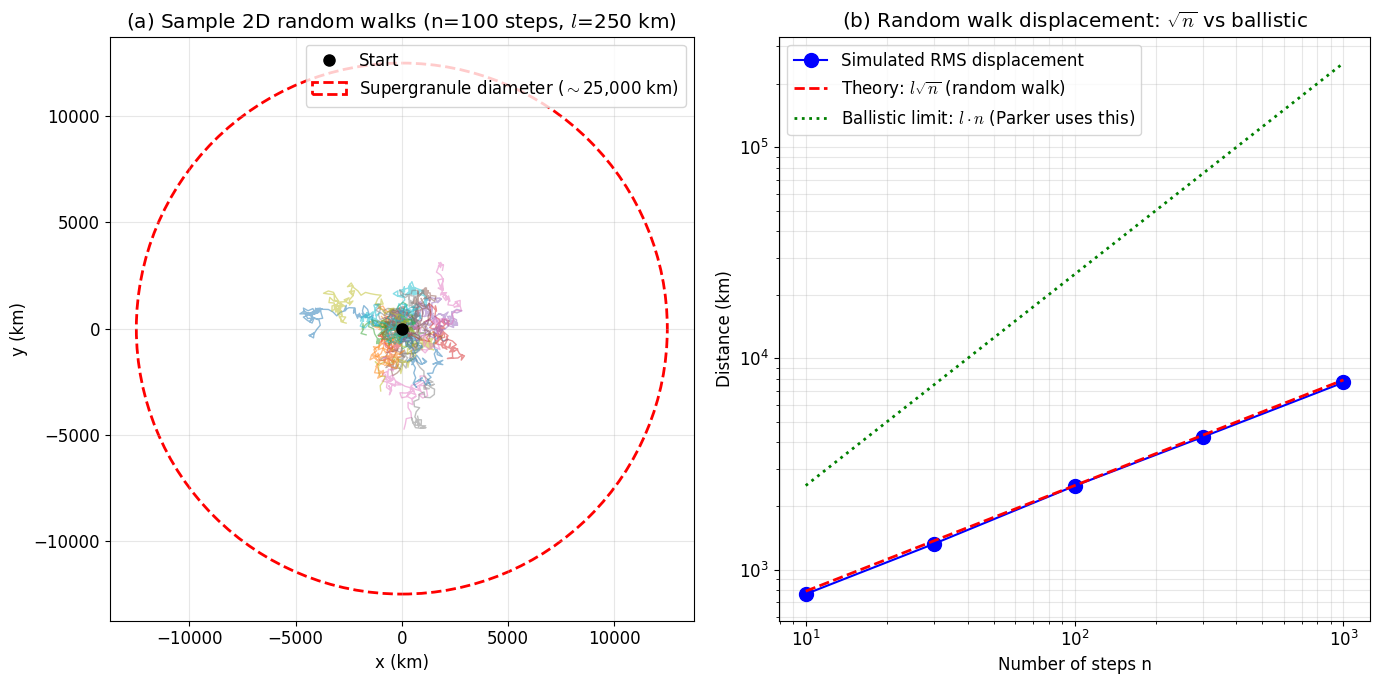


For n=100 steps of l=250 km:
  Random-walk RMS displacement: 2500 km
  Ballistic pathlength (Parker's vt): 25000 km
  Parker's '2.5e4 km = supergranule' is the *total pathlength*, not displacement.


In [6]:
def simulate_footpoint_walk(n_steps, l_step_km=250.0, n_realizations=50, seed=None):
    """Simulate 2D random walks of magnetic footpoints.

    Args:
        n_steps: Number of random steps.
        l_step_km: Step length in km.
        n_realizations: Number of independent walks.
        seed: RNG seed for reproducibility.

    Returns:
        Array of shape (n_realizations, n_steps+1, 2) of (x, y) trajectories in km.
    """
    local_rng = np.random.default_rng(seed)
    angles = local_rng.uniform(0, 2 * np.pi, size=(n_realizations, n_steps))
    dx = l_step_km * np.cos(angles)
    dy = l_step_km * np.sin(angles)
    x = np.concatenate([np.zeros((n_realizations, 1)), np.cumsum(dx, axis=1)], axis=1)
    y = np.concatenate([np.zeros((n_realizations, 1)), np.cumsum(dy, axis=1)], axis=1)
    return np.stack([x, y], axis=-1)


n_steps = 100  # active region: t_sat / tau = 5e4 / 500
trajectories = simulate_footpoint_walk(n_steps, l_step_km=250.0, n_realizations=20, seed=2026)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# (a) Sample trajectories
ax = axes[0]
for i in range(20):
    ax.plot(trajectories[i, :, 0], trajectories[i, :, 1], lw=1, alpha=0.5)
ax.plot(0, 0, 'ko', markersize=8, label='Start')
ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
ax.set_title(f'(a) Sample 2D random walks (n={n_steps} steps, $l$=250 km)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()

# Mark supergranule scale
supergran = plt.Circle((0, 0), 2.5e4 / 2, fill=False, ec='red', lw=2, ls='--',
                       label='Supergranule diameter ($\\sim$25,000 km)')
ax.add_patch(supergran)
ax.legend(loc='upper right')

# (b) Mean displacement vs sqrt(n)
n_steps_arr = np.array([10, 30, 100, 300, 1000])
rms_disp = []
for n in n_steps_arr:
    trajs = simulate_footpoint_walk(n, l_step_km=250.0, n_realizations=500, seed=2026)
    final_pos = trajs[:, -1, :]
    rms_disp.append(np.sqrt((final_pos**2).sum(axis=1).mean()))

ax = axes[1]
ax.loglog(n_steps_arr, rms_disp, 'bo-', markersize=10, label='Simulated RMS displacement')
ax.loglog(n_steps_arr, 250 * np.sqrt(n_steps_arr), 'r--', lw=2,
          label=r'Theory: $l \sqrt{n}$ (random walk)')
ax.loglog(n_steps_arr, 250 * n_steps_arr, 'g:', lw=2,
          label=r'Ballistic limit: $l \cdot n$ (Parker uses this)')
ax.set_xlabel('Number of steps n'); ax.set_ylabel('Distance (km)')
ax.set_title('(b) Random walk displacement: $\\sqrt{n}$ vs ballistic')
ax.grid(True, which='both', alpha=0.3); ax.legend()

plt.tight_layout()
plt.savefig('fig3_footpoint_walk.png', dpi=120)
plt.show()

print(f"\nFor n=100 steps of l=250 km:")
print(f"  Random-walk RMS displacement: {250 * np.sqrt(100):.0f} km")
print(f"  Ballistic pathlength (Parker's vt): {250 * 100:.0f} km")
print("  Parker's '2.5e4 km = supergranule' is the *total pathlength*, not displacement.")

**Subtlety / 미묘함**: Parker's $vt = 2.5 \times 10^4$ km is the **total integrated path** ($l \cdot n$), not the displacement from the origin (which scales as $l \sqrt{n} = 2500$ km). Both scales matter: the displacement controls how mixed up the field gets globally; the path controls how many tangential discontinuities form.

Parker의 $vt = 2.5 \times 10^4$ km은 원점으로부터의 변위가 아니라 **총 적분 경로** ($l \cdot n$). 변위는 $l \sqrt{n} = 2500$ km. 두 척도 모두 중요: 변위는 자기장이 얼마나 전체적으로 섞이는지를 제어; 경로는 얼마나 많은 접선 불연속면이 형성되는지를 제어.

## 4. Power-law statistics: when do nanoflares dominate? / 거듭제곱 통계: 언제 나노플레어가 지배하는가?

If the differential nanoflare distribution is $dN/dE \propto E^{-\alpha}$ with $E$ in $[E_\mathrm{min}, E_\mathrm{max}]$, then the total energy is
$$E_\text{total} = \int_{E_\mathrm{min}}^{E_\mathrm{max}} E \cdot N(E) \, dE \propto \int_{E_\mathrm{min}}^{E_\mathrm{max}} E^{1-\alpha} \, dE.$$

If $\alpha > 2$, this integral diverges as $E_\mathrm{min} \to 0$ — small events dominate the total energy budget, supporting the nanoflare hypothesis. If $\alpha < 2$, large events dominate.

$dN/dE \propto E^{-\alpha}$이고 $\alpha > 2$이면 $E_\mathrm{min} \to 0$에서 적분 발산 — 작은 사건이 총 에너지 예산 지배, 나노플레어 가설 지지. $\alpha < 2$이면 큰 사건 지배. **이것이 나노플레어 가설의 핵심 관측 시험**이며 35년 미해결.

/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33742/208418558.py:39: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33742/208418558.py:39: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33742/208418558.py:39: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33742/208418558.py:39: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_33742/208418558.py:39: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4y/4cm6rw9943nbqh9bl_m5c08r0000gn/T/ipykernel_337

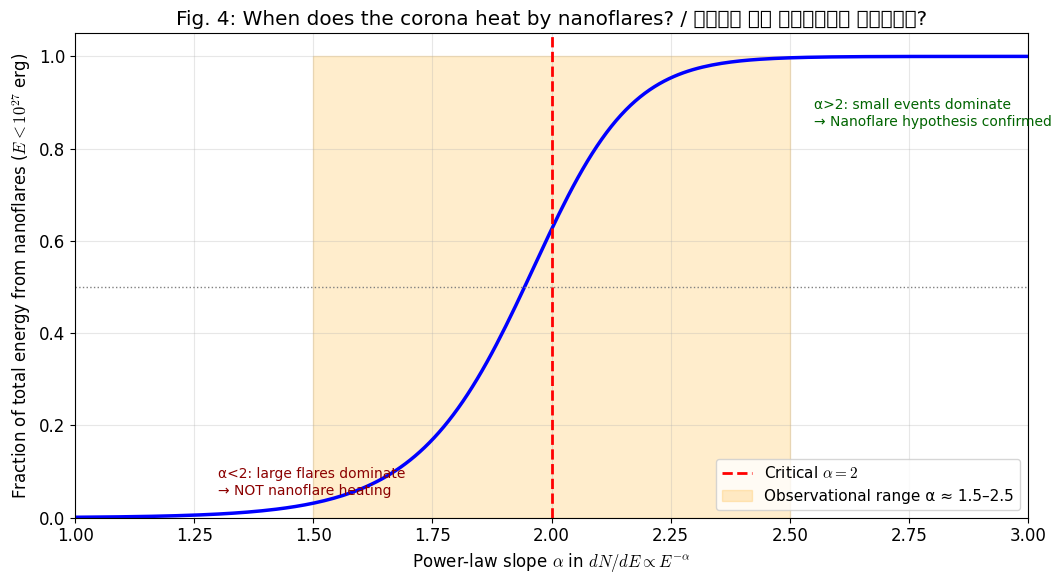


Fraction of total energy from events below 1e27 erg:
  α = 1.5:   3.2%
  α = 1.8:  23.2%
  α = 2.0:  62.5%
  α = 2.2:  92.3%
  α = 2.5:  99.7%


In [7]:
def total_energy_fraction(alpha, E_min, E_max, E_threshold):
    """Fraction of total energy in events below E_threshold.

    Assumes dN/dE ~ E^{-alpha}. Returns fraction of total integrated energy
    coming from events with E < E_threshold.
    """
    if abs(alpha - 2) < 1e-9:
        # Logarithmic case
        total = np.log(E_max / E_min)
        below = np.log(E_threshold / E_min)
        return below / total
    exponent = 2 - alpha
    total = (E_max**exponent - E_min**exponent) / exponent
    below = (E_threshold**exponent - E_min**exponent) / exponent
    return below / total


alphas = np.linspace(1.0, 3.0, 200)
E_min, E_max = 1e22, 1e30  # erg
E_threshold_micro = 1e27   # microflare threshold; "nano" = below this

frac_nano = np.array([total_energy_fraction(a, E_min, E_max, E_threshold_micro) for a in alphas])

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(alphas, frac_nano, 'b-', lw=2.5)
ax.axvline(2.0, color='r', ls='--', lw=2, label=r'Critical $\alpha = 2$')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.fill_betweenx([0, 1], 1.5, 2.5, alpha=0.2, color='orange',
                  label='Observational range α ≈ 1.5–2.5')
ax.set_xlabel(r'Power-law slope $\alpha$ in $dN/dE \propto E^{-\alpha}$')
ax.set_ylabel('Fraction of total energy from nanoflares ($E < 10^{27}$ erg)')
ax.set_title('Fig. 4: When does the corona heat by nanoflares? / 코로나는 언제 나노플레어로 가열되는가?')
ax.set_xlim(1.0, 3.0); ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3); ax.legend(loc='lower right', fontsize=11)
ax.text(1.3, 0.05, 'α<2: large flares dominate\n→ NOT nanoflare heating',
         fontsize=10, color='darkred')
ax.text(2.55, 0.85, 'α>2: small events dominate\n→ Nanoflare hypothesis confirmed',
         fontsize=10, color='darkgreen')
plt.tight_layout()
plt.savefig('fig4_powerlaw_threshold.png', dpi=120)
plt.show()

print('\nFraction of total energy from events below 1e27 erg:')
for a in [1.5, 1.8, 2.0, 2.2, 2.5]:
    f = total_energy_fraction(a, E_min, E_max, E_threshold_micro)
    print(f'  α = {a:.1f}: {f*100:5.1f}%')

## 5. Magnetic loop tilting: visualizing the heat-storage mechanism / 자기 루프 기울기: 가열 저장 메커니즘

Parker's geometric setup: a vertical magnetic flux bundle whose lower footpoint wanders, generating a tilt $\theta(t) = \arctan(vt/L)$. At $\theta \approx 14°$ reconnection ignites and erases the tilt. The magnetic free energy oscillates between buildup and release.

Parker의 기하 설정: 수직 자기 자속 다발의 하단 발점이 떠돌아 기울기 $\theta(t) = \arctan(vt/L)$ 생성. $\theta \approx 14°$에서 재결합 점화로 기울기 소멸. 자기 자유 에너지는 축적과 방출 사이를 진동.

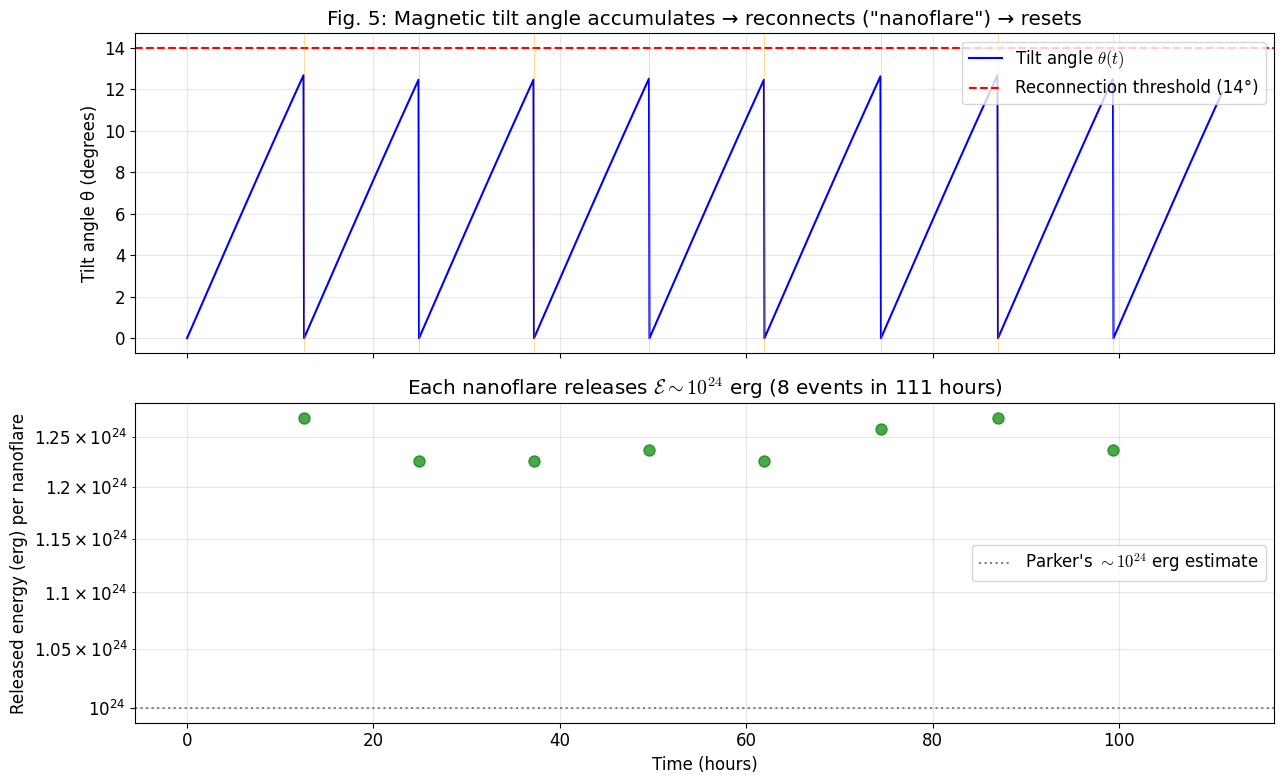


Simulation results / 시뮬레이션 결과:
  Total reconnection events: 8
  Mean event energy: 1.24e+24 erg
  Total released energy: 9.95e+24 erg
  Mean recurrence time: 12.4 hours

Parker's prediction: t_sat = 14 hr per event (active region)


In [8]:
def evolve_with_reconnection(B, v, L, theta_threshold_deg=14, t_total=2e5, dt=100.0):
    """Evolve the magnetic tilt angle with periodic reconnection events.

    The tilt grows linearly per Parker's Eq. 1; when it exceeds the threshold,
    a 'nanoflare' fires: tilt resets to zero and a reconnection burst is recorded.

    Args:
        B, v, L: As before.
        theta_threshold_deg: Reconnection threshold in degrees.
        t_total: Total simulation time in seconds.
        dt: Time step in seconds.

    Returns:
        Tuple (t_array, theta_array, reconnection_times, energies_released).
    """
    theta_threshold = np.radians(theta_threshold_deg)
    n_steps = int(t_total / dt)
    t_array = np.arange(n_steps) * dt
    theta_array = np.zeros(n_steps)
    reconn_times = []
    energies = []
    theta = 0.0
    t_since_reset = 0.0
    for i in range(n_steps):
        # Add jitter to mimic photospheric variability (≈30%)
        threshold = theta_threshold * (1 + 0.3 * (rng.random() - 0.5))
        if theta > threshold:
            # Reconnection event: release energy = (B_perp^2 / 8pi) * (some volume scale)
            B_perp = B * np.tan(theta)
            # Use Parker's E ~ l^2 dL B_perp^2 / 8pi with l=250km, dL=10^3km
            volume = (250e5)**2 * (1e3 * 1e5)
            energy = volume * B_perp**2 / (8 * np.pi)
            energies.append(energy)
            reconn_times.append(t_array[i])
            theta = 0.0
            t_since_reset = 0.0
        theta_array[i] = theta
        t_since_reset += dt
        theta = np.arctan(v * t_since_reset / L)
    return t_array, theta_array, np.array(reconn_times), np.array(energies)


t_arr, theta_arr, reconn_t, reconn_E = evolve_with_reconnection(
    B=100.0, v=0.5e5, L=1e10, theta_threshold_deg=14, t_total=4e5, dt=200.0
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Tilt angle vs time
ax = axes[0]
ax.plot(t_arr/3600, np.degrees(theta_arr), 'b-', lw=1.5, label='Tilt angle $\\theta(t)$')
ax.axhline(14, color='red', ls='--', lw=1.5, label='Reconnection threshold (14°)')
for tr in reconn_t:
    ax.axvline(tr/3600, color='orange', alpha=0.4, lw=0.7)
ax.set_ylabel('Tilt angle θ (degrees)')
ax.set_title(r'Fig. 5: Magnetic tilt angle accumulates → reconnects ("nanoflare") → resets')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Energy released per event
ax = axes[1]
ax.semilogy(reconn_t/3600, reconn_E, 'go', markersize=8, alpha=0.7)
ax.axhline(1e24, color='gray', ls=':', label=r"Parker's $\sim 10^{24}$ erg estimate")
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Released energy (erg) per nanoflare')
ax.set_title(f'Each nanoflare releases $\\mathcal{{E}} \\sim 10^{{24}}$ erg ({len(reconn_t)} events in {t_arr[-1]/3600:.0f} hours)')
ax.legend(); ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('fig5_loop_evolution.png', dpi=120)
plt.show()

print(f'\nSimulation results / 시뮬레이션 결과:')
print(f'  Total reconnection events: {len(reconn_t)}')
print(f'  Mean event energy: {reconn_E.mean():.2e} erg')
print(f'  Total released energy: {reconn_E.sum():.2e} erg')
print(f'  Mean recurrence time: {np.diff(reconn_t).mean()/3600:.1f} hours')
print(f"\nParker's prediction: t_sat = 14 hr per event (active region)")

## Summary / 요약

| Concept / 개념 | Parker's prediction (1988) | Modern status / 현대적 위상 |
|---|---|---|
| Heating power formula | $W = (B^2/4\pi)(v^2 t/L)$ | Verified by MHD simulations (van Ballegooijen, Rappazzo et al.) |
| Saturation timescale | $t_\mathrm{sat} \propto L$ — 14 hr for active regions | Consistent with TRACE/SDO observations |
| Reconnection threshold | $\theta \sim 14°$, $B_\perp \sim B/4$ | Reasonable; exact value depends on instability physics |
| Single nanoflare energy | $\mathcal{E} \sim 10^{24}$ erg | Below detection; statistical signatures only |
| Scale-invariance of $\mathcal{E}$ | Yes, by construction | Observed: X-ray brightness ~ independent of bipole size |
| Power-law slope $\alpha$ | Not predicted, but $\alpha > 2$ would confirm | Observed $\alpha \sim 1.5$–$2.5$ — undecided |
| Direct nanoflare detection | Future need (high-cadence, low-threshold) | Hi-C, IRIS get close; MUSE (~2027) may decide |

### Bottom line / 결론

**English**: Parker's 1988 paper made a clean, testable prediction with no fitting parameters: photospheric convection at $v \sim 0.5$ km/s on 100 G fields builds up coronal magnetic free energy that, if released as $\sim 10^{24}$ erg events, exactly accounts for the observed $10^7$ erg cm⁻² s⁻¹ heating requirement. Thirty-five years of observations have not falsified this — they have refined it. The scale-invariance argument remains one of the most elegant in solar physics.

**한국어**: Parker의 1988 논문은 맞춤 매개변수 없이 깔끔하고 검증 가능한 예측을 했다: 100 G 자기장 위 $v \sim 0.5$ km/s의 광구 대류가 코로나 자기 자유 에너지를 축적하고, 이것이 $\sim 10^{24}$ erg 사건들로 방출되면 관측된 $10^7$ erg cm⁻² s⁻¹ 가열 요구량을 정확히 설명한다. 35년의 관측은 이를 반증하지 못했고 — 정교화했다. 척도 불변성 논증은 태양물리학에서 가장 우아한 것 중 하나로 남아 있다.